# Setup

In [ ]:
!pip install -qU byaldi==0.0.4 pdf2image qwen-vl-utils transformers==4.45.0 requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.9 MB/s eta 0:00:00
   ━━━━━

Pakiety te wskazują na pracę z modelami językowymi i wizyjnymi:
- byaldi to narzędzie do pracy z modelami multimodalnymi
- pdf2image służy do konwertowania plików PDF na obrazy
- qwen-vl-utils to narzędzia związane z modelem Qwen VL (Vision-Language)
- transformers to biblioteka Hugging Face zawierająca implementacje różnych modeli transformerowych

In [ ]:
!sudo apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 186 kB of archives.
After this operation, 696 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.6 [186 kB]
Fetched 186 kB in 0s (586 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package poppler-utils.
(Reading database ... 124947 

Pakiet `poppler-utils` zawiera zestaw narzędzi do manipulacji plikami PDF. Znajdują się w nim programy takie jak:
- pdfinfo - wyświetlanie informacji o dokumencie PDF
- pdftotext - konwersja PDF na zwykły tekst
- pdftoppm - konwersja PDF na obrazy rastrowe
- pdftocairo - konwersja PDF do różnych formatów graficznych

In [ ]:
import requests
import os
import matplotlib.pyplot as plt
from pdf2image import convert_from_path
from byaldi import RAGMultiModalModel
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor
from qwen_vl_utils import process_vision_info
import torch

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"


In [ ]:
class CFG:
  rag = "vidore/colpali-v1.2"
  device = "cuda"
  model = "Qwen/Qwen2-VL-7B-Instruct"

# Funkcje

In [ ]:
def convert_pdfs_to_images(pdf_folder):
    pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith(".pdf")]
    all_images = {}

    for doc_id, pdf_file in enumerate(pdf_files):
        pdf_path = os.path.join(pdf_folder, pdf_file)
        images = convert_from_path(pdf_path)
        all_images[doc_id] = images

    return all_images


In [ ]:
def get_grouped_images(results, all_images):
    grouped_images = []

    for result in results:
        doc_id = result["doc_id"]
        page_num = result["page_num"]
        grouped_images.append(
            all_images[doc_id][page_num - 1]
        )  # page_num are 1-indexed, while doc_ids are 0-indexed. Source https://github.com/AnswerDotAI/byaldi?tab=readme-ov-file#searching

    return grouped_images

# Dane

In [ ]:
pdfs = {
    "MALM": "https://www.ikea.com/us/en/assembly_instructions/malm-4-drawer-chest-white__AA-2398381-2-100.pdf",
    "BILLY": "https://www.ikea.com/us/en/assembly_instructions/billy-bookcase-white__AA-1844854-6-2.pdf",
    "BOAXEL": "https://www.ikea.com/us/en/assembly_instructions/boaxel-wall-upright-white__AA-2341341-2-100.pdf",
    "ADILS": "https://www.ikea.com/us/en/assembly_instructions/adils-leg-white__AA-844478-6-2.pdf",
    "MICKE": "https://www.ikea.com/us/en/assembly_instructions/micke-desk-white__AA-476626-10-100.pdf",
}

output_dir = "/content/data"
os.makedirs(output_dir, exist_ok=True)

for name, url in pdfs.items():
    response = requests.get(url)
    pdf_path = os.path.join(output_dir, f"{name}.pdf")

    with open(pdf_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded {name} to {pdf_path}")

print("Downloaded files:", os.listdir(output_dir))

Downloaded MALM to /content/data/MALM.pdf
Downloaded BILLY to /content/data/BILLY.pdf
Downloaded BOAXEL to /content/data/BOAXEL.pdf
Downloaded ADILS to /content/data/ADILS.pdf
Downloaded MICKE to /content/data/MICKE.pdf
Downloaded files: ['MICKE.pdf', 'ADILS.pdf', 'MALM.pdf', 'BILLY.pdf', 'BOAXEL.pdf']


In [ ]:

all_images = convert_pdfs_to_images("/content/data/")

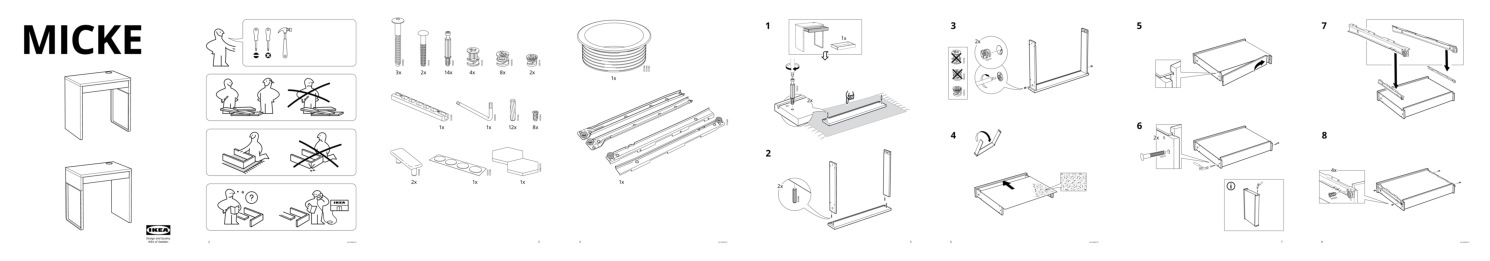

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    img = all_images[0][i]
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

Ten kod służy do wizualizacji pierwszych 8 stron instrukcji montażu mebla IKEA (najprawdopodobniej ADILS, choć kolejność może być inna). Daje to możliwość szybkiego przeglądu zawartości dokumentu:


Funkcja `plt.subplots()` tworzy figurę (`fig`) i siatkę wykresów (`axes`). Parametry wskazują, że:
- `1` - chcemy tylko jeden wiersz wykresów
- `8` - chcemy osiem kolumn (czyli osiem obrazów obok siebie)
- `figsize=(15, 10)` - definiuje rozmiar całej figury w calach (szerokość 15 cali, wysokość 10 cali)

- `axes.flat` to spłaszczona wersja tablicy wykresów, co pozwala iterować po wszystkich wykresach niezależnie od ich układu

- `all_images[0][i]` wybiera i-tą stronę z pierwszego dokumentu (o indeksie 0)
- `ax.imshow(img)` wyświetla ten obraz na polu wykresu
- `ax.axis("off")` wyłącza osie, dzięki czemu widać tylko obraz bez dodatkowych elementów wykresu

Funkcja `plt.tight_layout()` automatycznie dostosowuje układ, aby uniknąć nakładania się elementów i optymalnie wykorzystać dostępną przestrzeń. Jest to szczególnie przydatne, gdy mamy wiele wykresów na jednej figurze.

Funkcja `plt.show()` wyświetla figurę z wszystkimi obrazami.

# Model

In [ ]:

docs_retrieval_model = RAGMultiModalModel.from_pretrained(CFG.rag, verbose = 0, device = CFG.device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


adapter_config.json:   0%|          | 0.00/750 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/66.3k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

adapter_model.safetensors:   0%|          | 0.00/78.6M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/243k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

In [ ]:
docs_retrieval_model.index(
    input_path="data/",
    index_name="image_index",
    store_collection_with_index=False,
    overwrite=True,
)

Indexing file: data/MICKE.pdf


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


Indexing file: data/ADILS.pdf
Indexing file: data/MALM.pdf
Indexing file: data/BILLY.pdf
Indexing file: data/BOAXEL.pdf


{0: 'data/MICKE.pdf',
 1: 'data/ADILS.pdf',
 2: 'data/MALM.pdf',
 3: 'data/BILLY.pdf',
 4: 'data/BOAXEL.pdf'}

In [ ]:
text_query = "How many people are needed to assemble the Malm?"

results = docs_retrieval_model.search(text_query, k=3)
results

[{'doc_id': 2, 'page_num': 1, 'score': 15.3125, 'metadata': {}, 'base64': None},
 {'doc_id': 2, 'page_num': 3, 'score': 11.9375, 'metadata': {}, 'base64': None},
 {'doc_id': 3, 'page_num': 13, 'score': 11.875, 'metadata': {}, 'base64': None}]

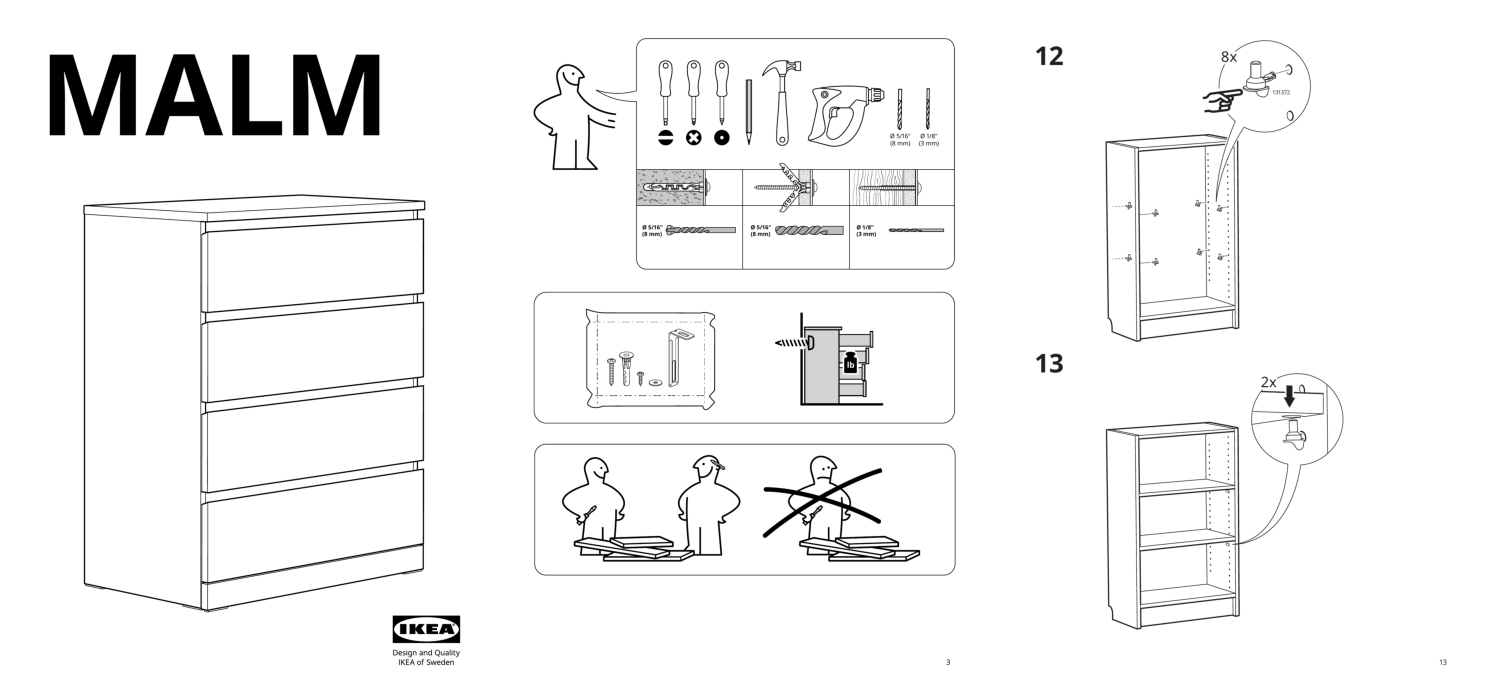

In [ ]:
grouped_images = get_grouped_images(results, all_images)


fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    img = grouped_images[i]
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

# VLM for QA

In [ ]:
vl_model = Qwen2VLForConditionalGeneration.from_pretrained(
    CFG.model,
    torch_dtype=torch.bfloat16,
).cuda()

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


model.safetensors.index.json:   0%|          | 0.00/56.5k [00:00<?, ?B/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/3.90G [00:00<?, ?B/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

...

model-00004-of-00005.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

In [ ]:
min_pixels = 224 * 224
max_pixels = 512 * 512
vl_model_processor = Qwen2VLProcessor.from_pretrained(
    CFG.model, min_pixels=min_pixels, max_pixels=max_pixels
)

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

# Kombinacja

In [ ]:
chat_template = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": grouped_images[0],
            },
            {
                "type": "image",
                "image": grouped_images[1],
            },
            {
                "type": "image",
                "image": grouped_images[2],
            },
            {"type": "text", "text": text_query},
        ],
    }
]

In [ ]:
text = vl_model_processor.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)

In [ ]:
image_inputs, _ = process_vision_info(chat_template)
inputs = vl_model_processor(
    text=[text],            # tekst w formie listy
    images=image_inputs,    # przetworzone obrazy
    padding=True,           # dodaje padding do ujednolicenia długości
    return_tensors="pt",    # zwraca tensory PyTorch
)
inputs = inputs.to(CFG.device)

In [ ]:
generated_ids = vl_model.generate(**inputs, max_new_tokens=100)

In [ ]:
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = vl_model_processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

In [ ]:
print(output_text[0])

The Malm requires two people to assemble it.


# Alles zusammen

In [ ]:
def answer_with_multimodal_rag(
    vl_model,
    docs_retrieval_model,
    vl_model_processor,
    grouped_images,
    text_query,
    top_k,
    max_new_tokens,
):
    results = docs_retrieval_model.search(text_query, k=top_k)
    grouped_images = get_grouped_images(results, all_images)

    chat_template = [
        {
            "role": "user",
            "content": [{"type": "image", "image": image} for image in grouped_images]
            + [{"type": "text", "text": text_query}],
        }
    ]

    # Prepare the inputs
    text = vl_model_processor.apply_chat_template(
        chat_template, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(chat_template)
    inputs = vl_model_processor(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to("cuda")

    # Generate text from the vl_model
    generated_ids = vl_model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    # Decode the generated text
    output_text = vl_model_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    return output_text

Ta funkcja jest sercem systemu pytań i odpowiedzi, łącząc wyszukiwanie kontekstu z generowaniem odpowiedzi multimodalnych. Przyjrzyjmy się jej działaniu krok po kroku:

### Parametry funkcji

Funkcja przyjmuje kilka kluczowych elementów:
- `vl_model` - model wizyjno-językowy (Qwen2VL), który będzie generował odpowiedzi
- `docs_retrieval_model` - model RAG odpowiedzialny za wyszukiwanie istotnych fragmentów dokumentów
- `vl_model_processor` - procesor, który przygotowuje dane do formatu wymaganego przez model
- `grouped_images` - obrazy stron z instrukcji (chociaż są ponownie pobierane wewnątrz funkcji)
- `text_query` - pytanie użytkownika
- `top_k` - liczba najlepszych fragmentów do pobrania z wyszukiwania
- `max_new_tokens` - maksymalna liczba tokenów do wygenerowania w odpowiedzi

### Wyszukiwanie kontekstu

```python
results = docs_retrieval_model.search(text_query, k=top_k)
grouped_images = get_grouped_images(results, all_images)
```

Tutaj model RAG wyszukuje fragmenty dokumentów najbardziej odpowiadające pytaniu użytkownika. Parametr `k=top_k` określa, ile najlepszych wyników ma zostać zwróconych. Następnie funkcja `get_grouped_images` zamienia te wyniki na konkretne obrazy stron z instrukcji.

### Formatowanie zapytania

```python
chat_template = [
    {
        "role": "user",
        "content": [{"type": "image", "image": image} for image in grouped_images]
        + [{"type": "text", "text": text_query}],
    }
]
```

To jest ciekawy element, który pokazuje, jak działa komunikacja multimodalna z modelem. Tworzymy szablon rozmowy, gdzie "użytkownik" wysyła zarówno obrazy, jak i tekst. Obrazy są dodawane jako osobne elementy zawartości typu "image", a pytanie użytkownika jako element typu "text". Ta struktura pozwala modelowi zrozumieć, że powinien analizować obrazy w kontekście pytania.

### Przygotowanie danych wejściowych

```python
text = vl_model_processor.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(chat_template)
inputs = vl_model_processor(
    text=[text],
    images=image_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")
```

Ta część przygotowuje dane do formatu wymaganego przez model:
1. `apply_chat_template` konwertuje szablon rozmowy na format tekstowy zrozumiały dla modelu
2. `process_vision_info` wydobywa informacje wizualne z szablonu rozmowy
3. Procesor modelu łączy tekst i obrazy w jednolity format wejściowy
4. Dane są przenoszone na GPU za pomocą `.to("cuda")`

### Generowanie odpowiedzi

```python
generated_ids = vl_model.generate(**inputs, max_new_tokens=max_new_tokens)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
```

Model generuje odpowiedź na podstawie przygotowanych danych wejściowych. Warto zauważyć, że odpowiedź jest początkowo w formie identyfikatorów tokenów, które muszą zostać później zdekodowane.

Interesujący jest wiersz z `generated_ids_trimmed` - odcina on identyfikatory tokenów wejściowych z wygenerowanej sekwencji. Jest to konieczne, ponieważ model zwykle zwraca całą sekwencję (wejście + wygenerowana odpowiedź), ale my chcemy tylko nową część.

### Dekodowanie wygenerowanego tekstu

```python
output_text = vl_model_processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
```

Tutaj identyfikatory tokenów są przekształcane z powrotem na tekst. Parametry wskazują, że specjalne tokeny (jak znaczniki końca sekwencji) powinny być pomijane, ale spacje dodane podczas tokenizacji powinny pozostać nietknięte.

### Zwracanie wyniku

```python
return output_text
```

Funkcja zwraca zdekodowany tekst, który zawiera odpowiedź modelu na pytanie użytkownika, bazującą na kontekście wizualnym z instrukcji montażu.

Ta funkcja stanowi kompleksowe rozwiązanie łączące wyszukiwanie informacji wizualnych z generowaniem odpowiedzi. Jest to doskonały przykład przetwarzania multimodalnego, gdzie system musi rozumieć zarówno tekst (pytanie użytkownika), jak i obrazy (instrukcje montażu), a następnie tworzyć odpowiedź, która sensownie odnosi się do obu tych modalności.

In [ ]:
output_text = answer_with_multimodal_rag(
    vl_model=vl_model,
    docs_retrieval_model=docs_retrieval_model,
    vl_model_processor=vl_model_processor,
    grouped_images=grouped_images,
    text_query="How do I assemble the Micke desk?",
    top_k=3,
    max_new_tokens= 250,
)
print(output_text[0])

To assemble the Micke desk, follow these steps:

1. Unpack the desk and its components.
2. Locate the desk legs and attach them to the desk top using the provided screws.
3. Attach the desk top to the legs.
4. Ensure all screws are tightened securely.

Refer to the provided instructions for detailed assembly steps and any additional components or tools required.
